# Demo Notebook: Transfer Learning for Text Classification

This demo uses a **real text-classification task** rather than a tiny synthetic example.

The notebook compares two routes:

- a conventional baseline using **TF-IDF + logistic regression**;
- a transfer-learning route using **pretrained sentence embeddings + logistic regression**.

It uses a small balanced subset of a built-in scikit-learn text dataset instead of a heavier external dataset pipeline.

This makes the demo more robust for live teaching while still showing a real baseline comparison on a real task.

## Before you run

This notebook is designed to be reasonable on a laptop or desktop CPU.

It uses scikit-learn's built-in `fetch_20newsgroups`.

The pretrained embedding model will still download the first time you run the notebook, so the first pass will be slower than reruns.

In [ ]:
import importlib.util
import subprocess
import sys

package_name = 'sentence-transformers'
module_name = 'sentence_transformers'

if importlib.util.find_spec(module_name) is None:
    print(f'Installing {package_name}...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', package_name],
        check=True,
    )
else:
    print(f'{package_name} is already installed.')

print('Setup complete. If the kernel reports package changes, restart it and run the next cell.')

Found existing installation: datasets 4.8.2
Uninstalling datasets-4.8.2:
  Successfully uninstalled datasets-4.8.2
Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
Setup complete. If the kernel reports package changes, restart it and run the next cell.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.datasets import fetch_20newsgroups

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## 1. Load a real text-classification dataset



We use a two-class subset of the scikit-learn 20 Newsgroups dataset. This keeps the demo lightweight and avoids heavier dataset dependencies, while still giving us a real text task to compare representations on.



The original dataset categories in this notebook are:



- `sci.med`

- `sci.space`



For display in tables and plots, we shorten those labels to `med` and `space`.

In [ ]:
categories = ['sci.med', 'sci.space']

train_data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)



test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

label_names = ['med', 'space']

train_df = pd.DataFrame({'text': train_data.data, 'label': train_data.target})
test_df = pd.DataFrame({'text': test_data.data, 'label': test_data.target})
train_df['label_name'] = train_df['label'].map(dict(enumerate(label_names)))
test_df['label_name'] = test_df['label'].map(dict(enumerate(label_names)))

display(train_df.head())
print('Training rows:', len(train_df))
print('Test rows:', len(test_df))

,text,label,label_name
0,"From: ""Phil G. Fraering"" <pgf@srl03.cacs.usl.e...",1,space
1,"\nIt isn't that rare, actually. Many cases th...",0,med
2,"I have between 15 and 25 nosebleeds each week,...",0,med
3,\nIt depends on the cause of the pneumonia. F...,0,med
4,Is there a few Grasp pictures of space related...,1,space


Training rows: 1187
Test rows: 790


In [16]:
def balanced_sample(df, n_per_class, label_col='label', random_state=42):
    sampled_frames = [
        frame.sample(min(len(frame), n_per_class), random_state=random_state)
        for _, frame in df.groupby(label_col, sort=True)
    ]
    return pd.concat(sampled_frames, ignore_index=True)


train_small = balanced_sample(train_df, n_per_class=250)
test_small = balanced_sample(test_df, n_per_class=150)

print(train_small['label_name'].value_counts().sort_index())
print(test_small['label_name'].value_counts().sort_index())
print('train_small columns:', train_small.columns.tolist())
print('test_small columns:', test_small.columns.tolist())

label_name
med      250
space    250
Name: count, dtype: int64
label_name
med      150
space    150
Name: count, dtype: int64
train_small columns: ['text', 'label', 'label_name']
test_small columns: ['text', 'label', 'label_name']


,text,label_name
361,\n[ a nearly perfect parody -- needed more ra...,space
73,Does the Proventil inhaler for asthma relief f...,med
374,I am doing a political science paper on the fu...,space
155,\n\ndoes anyone know?\n\n--,med
104,"[From Kalat, J.W.. (1992): _Biological Psycho...",med
394,A brief political/cultural item.\n\nRadio stat...,space
377,"\nWell said.\n \n\nOkay, Del, so Michael was b...",space
124,Mark McWiggins <markmc@halcyon.com> reminds us...,med


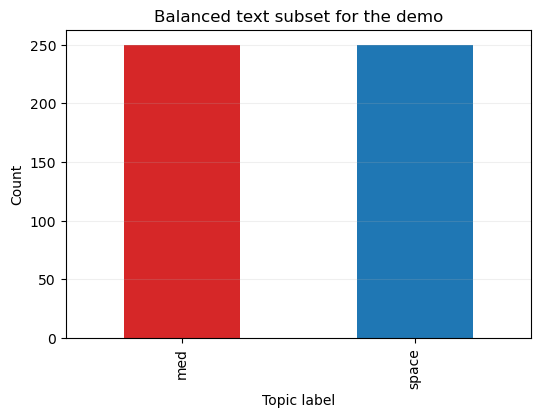

In [ ]:
display(train_small[['text', 'label_name']].sample(8, random_state=42))

train_small['label_name'].value_counts().sort_index().plot(kind='bar', figsize=(6, 4), color=['tab:red', 'tab:blue'])
plt.xlabel('Topic label')
plt.ylabel('Count')
plt.title('Balanced text subset for the demo')
plt.grid(True, axis='y', alpha=0.2)
plt.show()

## 2. Baseline: TF-IDF + logistic regression

This baseline is sensible because TF-IDF is a standard conventional text representation. It gives us something fair to compare against.

In [18]:
tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_small['text'])
X_test_tfidf = tfidf.transform(test_small['text'])

tfidf_clf = LogisticRegression(max_iter=1000)
tfidf_clf.fit(X_train_tfidf, train_small['label'])
tfidf_preds = tfidf_clf.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(test_small['label'], tfidf_preds)
tfidf_f1 = f1_score(test_small['label'], tfidf_preds, average='weighted')

print('TF-IDF accuracy:', round(tfidf_accuracy, 3))
print('TF-IDF weighted F1:', round(tfidf_f1, 3))

TF-IDF accuracy: 0.863
TF-IDF weighted F1: 0.863


## 3. Transfer-learning route: pretrained sentence embeddings

We now keep the downstream classifier simple and change only the representation. The embedding model has already learned a rich language representation from large text corpora.

In [19]:
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X_train_embed = embedder.encode(train_small['text'].tolist(), batch_size=32, show_progress_bar=True)
X_test_embed = embedder.encode(test_small['text'].tolist(), batch_size=32, show_progress_bar=True)

embed_clf = LogisticRegression(max_iter=1000)
embed_clf.fit(X_train_embed, train_small['label'])
embed_preds = embed_clf.predict(X_test_embed)

embed_accuracy = accuracy_score(test_small['label'], embed_preds)
embed_f1 = f1_score(test_small['label'], embed_preds, average='weighted')

print('Embedding accuracy:', round(embed_accuracy, 3))
print('Embedding weighted F1:', round(embed_f1, 3))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9336.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 10/10 [00:02<00:00,  4.92it/s]

Embedding accuracy: 0.923
Embedding weighted F1: 0.923


In [20]:
results = pd.DataFrame({
    'model': ['TF-IDF + logistic regression', 'Sentence embeddings + logistic regression'],
    'accuracy': [tfidf_accuracy, embed_accuracy],
    'weighted_f1': [tfidf_f1, embed_f1]
})
display(results)

print('Classification report for sentence embeddings:')
print(classification_report(test_small['label'], embed_preds, target_names=label_names))

,model,accuracy,weighted_f1
0,TF-IDF + logistic regression,0.863333,0.862991
1,Sentence embeddings + logistic regression,0.923333,0.923312


Classification report for sentence embeddings:
              precision    recall  f1-score   support

         med       0.91      0.94      0.92       150
       space       0.94      0.91      0.92       150

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



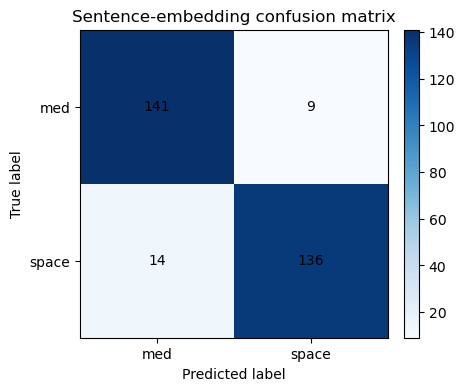

In [21]:
cm = confusion_matrix(test_small['label'], embed_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Sentence-embedding confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Interpretation

Use this result to discuss:

- why TF-IDF is a fair conventional baseline for text classification;
- why pretrained sentence embeddings may help when meaning matters more than word counts alone;